# Evaluation on Modes of Climate Variability: Pacific North-Atlantic Bias

# Libraries

In [1]:
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
from matplotlib.colors import BoundaryNorm, ListedColormap, Normalize
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.ticker import ScalarFormatter
from matplotlib.colors import TwoSlopeNorm
from typing import Dict, Tuple, AnyStr
from matplotlib import pyplot as plt
from shapely.geometry import Polygon
import matplotlib.colors as mcolors
import cartopy.feature as cfeature
import matplotlib.path as mpath
import cartopy.util as cutil
import cartopy.crs as ccrs
import matplotlib.cm as cm
import xarray as xr
import pandas as pd
import numpy as np
import cftime
import torch
import pywt 
import glob
import cv2
import os

os.chdir('..')

#from library.candidate_metrics.wavelets.WAVESIMSV_Final import WaveSimSVFinal
#from library.candidate_metrics.wavelets.WAVESIMSV import WaveSimSV
#from library.candidate_metrics.wavelets.WAVESIM import WaveSim
#from library.candidate_metrics.pointwise.Normalized_RMSE import NormalizedRootMeanSquaredError
#from library.candidate_metrics.structural.DSSIM import DataStructuralSimilarityIndex

from metrics import NormalizedRootMeanSquaredError, DataStructuralSimilarityIndex
from wavesim import WaveSim

%load_ext autoreload
%autoreload 2

# Data

In [2]:
# Build 'DJF year' label: December belongs to the *previous* year's DJF
def get_djf_year(time):
    return xr.where(time.dt.month == 12, time.dt.year + 1, time.dt.year)

In [4]:
print(os.getcwd())

/Users/gabrieleaccarino/Workspace/wavesim/wavesim


## Load Observations

In [ ]:
years = np.arange(1979, 2015, 1) # 37 years
months = [12, 1, 2] # DJF

### OBS ###
level = 500.0
obs_path = '../data/reanalysis/hgt.mon.mean.73x144.nc'
Z500_obs = xr.open_dataset(obs_path).sel(level = level)
Z500_obs = Z500_obs.sortby('time')

tmp = Z500_obs.where(Z500_obs['time'].dt.month.isin(months), drop=True)
tmp.coords['djf_year'] = get_djf_year(tmp['time'])
tmp = tmp.sel(time=tmp['djf_year'].isin(years))
DJF_seasonal = tmp.groupby('djf_year').mean(dim='time')     # shape: (djf_year, lat, lon)

lons = DJF_seasonal.lon.values
lats = DJF_seasonal.lat.values
lons, lats = np.meshgrid(lons, lats)

Z500_obs_mean = DJF_seasonal.mean(dim='djf_year')['hgt']    # shape: (lat, lon)

## Load Earth System Model Data

In [9]:
var = 'zg'
esm_base_path = f'../data/CMIP6_monthly_data/remapped/{var}'
ESM = ['CESM2', 'CMCC-CM2-HR4'] #, 'GFDL-ESM4', 'MIROC6']
ESM_climatologies = {}
plev = 50000.
###

for esm in ESM:
    esm_path = glob.glob(f'{esm_base_path}/{esm}_{var}_*.nc')[0]
    esm_df = xr.open_dataset(esm_path)
    esm_df = esm_df.sortby('time')

    # select the geopotential level
    esm_df = esm_df.sel(plev = plev)

    # Convert the time format
    try:
        formatted_times = [pd.to_datetime(t.strftime('%Y-%m-%dT%H:%M:%S') + '.000000000') for t in esm_df['time'].values]
        formatted_times = np.array(formatted_times, dtype='datetime64[ns]')
        esm_df.coords['time'] = ('time', formatted_times)
    except:
        pass

    # Select months in DJF
    tmp = esm_df.where(esm_df['time'].dt.month.isin(months), drop=True)
    # Build 'DJF year' label: December belongs to the *previous* year's DJF
    tmp.coords['djf_year'] = get_djf_year(tmp['time'])
    # Select only DJFs that fall within 1979–2014
    tmp = tmp.sel(time=tmp['djf_year'].isin(years))
    # Now compute seasonal DJF mean for each DJF year
    DJF_seasonal = tmp.groupby('djf_year').mean(dim='time')     # (djf_year, lat, lon)
    # Compute climatology (1979–2014 average)
    DJF_climatology = DJF_seasonal.mean(dim='djf_year')         # (lat, lon)

    ESM_climatologies[esm] = DJF_climatology[var]

list(ESM_climatologies.keys())

['CESM2', 'CMCC-CM2-HR4']

# Plot : Figure X of the Paper

0 CESM2
1 CMCC-CM2-HR4


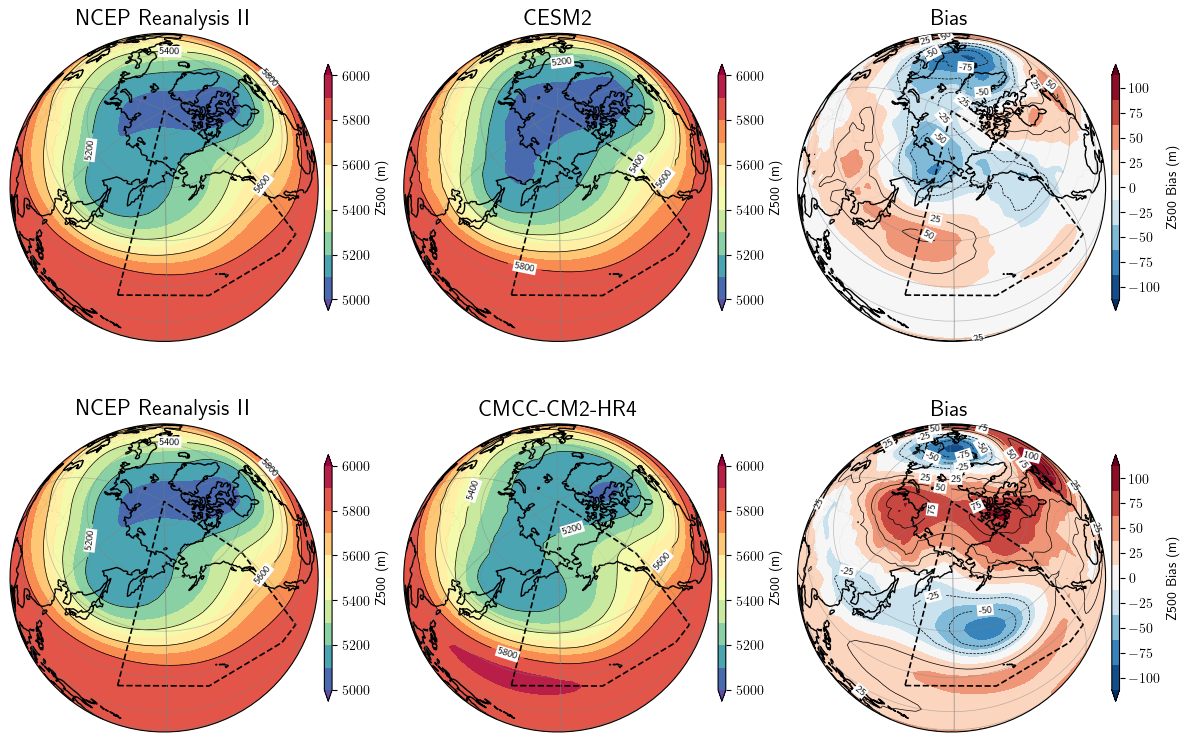

In [10]:
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'sans-serif'

fig, axs = plt.subplots(len(ESM), 3, figsize=(12, 8), subplot_kw={'projection': ccrs.Orthographic(central_longitude=179, central_latitude=60.25)})

vmin, vmax = 5000, 6000
#levels_obs = np.arange(vmin, vmax + 1, 50)  # fine for contours
levels_obs = np.arange(vmin, vmax + 1, 100)  # fine for contours
ticks_obs = np.arange(vmin, vmax + 1, 200)  # coarser for colorbar

vmin_bias, vmax_bias = -100, 100
step = 25
boundaries = np.arange(-112.5, 112.6, step) #np.arange(vmin_bias, vmax_bias + step, step)
ticks_bias = np.arange(vmin_bias, vmax_bias + 1, step)
#n_bins = len(boundaries) - 1
#cmap_base = plt.get_cmap('RdBu_r', n_bins)
#colors = cmap_base(np.linspace(0, 1, n_bins))
#zero_bin_index = np.where((boundaries[:-1] < 0) & (boundaries[1:] > 0))[0][0]  # Find bin that spans 0
#colors[zero_bin_index] = [1, 1, 1, 1]  # white
#colors[n_bins // 2] = [1, 1, 1, 1]  # set center bin to pure white
#cmap_custom = ListedColormap(colors)
#norm = TwoSlopeNorm(vmin=vmin_bias, vcenter=0.0, vmax=vmax_bias)
#norm = BoundaryNorm(boundaries, ncolors=n_bins)

# for circle-style plots
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)

# Coordinates for bounding box
lon_min, lon_max = 161, 240
lat_min, lat_max = 12.5, 90
box_coords = [(lon_min, lat_min), (lon_max, lat_min), (lon_max, lat_max), (lon_min, lat_max), (lon_min, lat_min)]
box = Polygon(box_coords)

for i, esm in enumerate(ESM):
    print(i, esm)
    obs = Z500_obs_mean  # Observational climatology
    esm_map = ESM_climatologies[esm]  # Model climatology
    bias_map = (esm_map - obs)
    for j, data in enumerate([obs, esm_map, bias_map]):
        ax = axs[i, j]
        data_ = data  # Convert to meters
        data_cyc, lons_, lats_ = cutil.add_cyclic(data_, lons, lats)
        
        if j == 2:
            cax = ax.inset_axes([1.02, 0.1, 0.025, 0.8])
            #im = ax.contourf(lons_, lats_, data_cyc, levels=boundaries, cmap=cmap_custom, norm=norm, extend='both', transform=ccrs.PlateCarree())
            im = ax.contourf(lons_, lats_, data_cyc, levels=boundaries, cmap='RdBu_r', extend='both', transform=ccrs.PlateCarree())
            contour_levels = [-100, -75, -50, -25, 25, 50, 75, 100]
            CS = ax.contour(lons_, lats_, data_cyc, levels=contour_levels, colors='black', linewidths=0.5, transform=ccrs.PlateCarree())
            cbar = fig.colorbar(im, cax=cax, orientation='vertical', ticks=ticks_bias)
            cbar.set_label('Z500 Bias (m)')
            #contour_levels = [-100, -50, -25, 25, 50, 100]
        elif j == 1:
            cax = ax.inset_axes([1.02, 0.1, 0.025, 0.8])
            im = ax.contourf(lons_, lats_, data_cyc, levels=levels_obs, cmap='Spectral_r', extend='both', transform=ccrs.PlateCarree()) # Spectral_r
            contour_levels = [5000, 5200, 5400, 5600, 5800, 6000]
            CS = ax.contour(lons_, lats_, data_cyc, levels=contour_levels, colors='black', linewidths=0.5, linestyles='solid', transform=ccrs.PlateCarree())
            cbar = fig.colorbar(im, cax=cax, orientation='vertical', extend='both', ticks=ticks_obs)
            cbar.set_label(label='Z500 (m)')
        else:
            cax = ax.inset_axes([1.02, 0.1, 0.025, 0.8])
            im = ax.contourf(lons_, lats_, data_cyc, levels=levels_obs, cmap='Spectral_r', extend='both', transform=ccrs.PlateCarree()) # Spectral_r
            contour_levels = [5000, 5200, 5400, 5600, 5800, 6000]
            CS = ax.contour(lons_, lats_, data_cyc, levels=contour_levels, colors='black', linewidths=0.5, linestyles='solid', transform=ccrs.PlateCarree())
            cbar = fig.colorbar(im, cax=cax, orientation='vertical', extend='both', ticks=ticks_obs)
            cbar.set_label(label='Z500 (m)')

        ax.add_geometries([box], crs=ccrs.PlateCarree(), edgecolor='black', facecolor='none', linewidth=1.2, linestyle='dashed')
        clabels = ax.clabel(CS, inline=True, inline_spacing=5, fontsize=7, fmt='%d')
        for txt in clabels:
            txt.set_bbox(dict(facecolor='white', edgecolor='none', pad=1.0))

        title = f"{'NCEP Reanalysis II' if j==0 else (f'{esm}' if j==1 else f'Bias')}"
        ax.set_title(title, fontsize=16)
        ax.gridlines(draw_labels=False, linewidth=0.5, color='gray', alpha=0.5)
        ax.coastlines()
        ax.add_feature(cfeature.BORDERS, linestyle=':', alpha=0.5, linewidth=0.1)
        ax.set_boundary(circle, transform=ax.transAxes)
        
# Shared colorbar
#cax = fig.add_axes([0.25, 0.08, 0.5, 0.02])
#fig.colorbar(im, ax=axs.ravel().tolist(), cax=cax, orientation='horizontal', ticks=ticks, label='Z500 (m)')
plt.subplots_adjust(
    left=0.05, right=0.95, top=0.95, bottom=0.05,
    wspace=0.27,  # horizontal space between columns, reduce from default (~0.2)
    hspace=0.3   # vertical space between rows, reduce from default (~0.2)
)
plt.tight_layout(rect=[0, 0, 1, 1])
plt.show()
#plt.savefig('intensity_scale_verification/biases/figs/Z500_bias_2_esm.png', dpi=300)

# Benchmark

In [11]:
wavesim_params = {'wavelet': 'db2',
                'mode': 'symmetric',
                'levels': 3,
                'operation': 'sum',
                'components_weight': {'alpha': 1.0, 'beta': 1.0, 'gamma': 1.0},
                'scales_weight': [0.33, 0.33, 0.33], # TODO : transform in a tensor (B, C, L+1)
                'use_approx' : False,
                }

nrsme_params = {'mode' : 'range'}

dssim_params = {'C1' : 1.0e-8, 
                'C2' : 1.0e-8, 
                'k' : 5, 
                'x_stddev' : 1.5, 
                'x_size' : 11, 
                'y_size' : 11, 
                'discretize' : True,
                'return_contrast' : False}

## Scores DataFrame

In [43]:
scores = pd.DataFrame(columns=['Earth System Model', 
                               'nrmse', 
                               'dssim', 
                               'wavesim',
                               'wavesim_components',
                               ]).astype({
                                        'Earth System Model': 'str', 
                                        'nrmse': np.float32,
                                        'dssim': np.float32,
                                        'wavesim': np.float32,
                                        'wavesim_components': 'str',
                                        })

## Run the Benchmark and get metrics scores

In [73]:
Z500_obs_pna = torch.Tensor(Z500_obs_mean.sel(lat=slice(90, 12.5), lon=slice(161, 240)).values.copy()).unsqueeze(0).unsqueeze(0)

for _, esm in enumerate(ESM):  
    print(f'Processing {esm}...')
    Z500_esm_pna = torch.Tensor(ESM_climatologies[esm].sel(lat=slice(90, 12.5), lon=slice(161, 240)).values.copy()).unsqueeze(0).unsqueeze(0)

    nrmse_score = NormalizedRootMeanSquaredError(map1=Z500_obs_pna, map2=Z500_esm_pna, params=nrsme_params).compute()
    dssim_score = DataStructuralSimilarityIndex(map1=Z500_obs_pna, map2=Z500_esm_pna, params=dssim_params).compute()
    
    wavesim = WaveSim(map1=Z500_obs_pna, map2=Z500_esm_pna, params=wavesim_params)
    
    wavesim_score = wavesim.compute()
    wavesim_components = {'magnitude': wavesim.magnitude_sim_score.numpy().ravel(),
                          'displacement': wavesim.displacement_sim_score.numpy().ravel(), 
                          'structure' : wavesim.structural_sim_score.numpy().ravel()
                          }
    
    new_row = pd.DataFrame({'Earth System Model' : [esm],
                                'nrmse' : [nrmse_score],
                                'dssim' : [dssim_score],
                                'wavesim' : [wavesim_score],
                                'wavesim_components' : [wavesim_components]
                                })

    scores = pd.concat([scores, new_row], ignore_index=True)

Processing CESM2...
Processing CMCC-CM2-HR4...


In [45]:
scores

,Earth System Model,nrmse,dssim,wavesim,wavesim_components
0,CESM2,0.96908,0.950137,0.835723,"{'magnitude': [0.96281064, 0.927211, 0.9038525..."
1,CMCC-CM2-HR4,0.94310,0.857830,0.656344,"{'magnitude': [0.7937984, 0.83416045, 0.708700..."


# Convert a Pandas DataFrame to a Markdown-formatted Table

In [46]:
import pandas as pd

def dataframe_to_markdown_table(df: pd.DataFrame, output_file: str):
    """
    Convert a DataFrame into a markdown file with the nested table structure.

    Expected DataFrame columns:
    - 'Test Case' (str)
    - 'NRMSE' (float)
    - 'DSSIM' (float)
    - 'WaveSim' (float)
    - 'Magnitude' (list/array of floats)
    - 'Displacement' (list/array of floats)
    - 'Structure' (list/array of floats)
    """

    header = """## Similarity scores between reference map (a) and perturbed maps (b–i)

<table align="center; adding: 0; line-height: 1.1">
  <tr>
    <th style="font-size: 1.2em;">Test Case</th>
    <th style="font-size: 1.2em;">NRMSE</th>
    <th style="font-size: 1.2em;">DSSIM</th>
    <th style="font-size: 1.2em;">WaveSim (ours)</th>
    <th align="center">
      <div style="font-size: 1.2em;">WaveSim Components</div>
      <div style="font-size: 0.9em; font-weight: normal;">Spatial Resolution: 0.25°; Scales (km): ~50, 100, 200, 360, 360</div>
    </th>
  </tr>
"""
    rows = []
    for _, row in df.iterrows():
        # Ensure lists are formatted like [0.123 0.456 ...]
        magnitude = "[" + " ".join(f"{x:.3f}" for x in row["wavesim_components"]["magnitude"]) + "]"
        displacement = "[" + " ".join(f"{x:.3f}" for x in row["wavesim_components"]["displacement"]) + "]"
        structure = "[" + " ".join(f"{x:.3f}" for x in row["wavesim_components"]["structure"]) + "]"

        rows.append(f"""
  <tr>
    <td align="center" style="font-size: 1.2em;">{row['Test Case']}</td>
    <td align="center" style="font-size: 1.2em;">{row['NRMSE']:.3f}</td>
    <td align="center" style="font-size: 1.2em;">{row['DSSIM']:.3f}</td>
    <td align="center" style="font-size: 1.2em;">{row['WaveSim']:.3f}</td>
    <td>
      <table style="font-family: monospace; border-collapse: collapse; adding: 0; line-height: 1.1">
        <tr><td>Magnitude   </td><td>{magnitude}</td></tr>
        <tr><td>Displacement</td><td>{displacement}</td></tr>
        <tr><td>Structure   </td><td>{structure}</td></tr>
      </table>
    </td>
  </tr>
""")

    footer = "</table>\n"

    markdown_content = header + "".join(rows) + footer

    # Save to file
    with open(output_file, "w") as f:
        f.write(markdown_content)

    print(f"Markdown table saved to {output_file}")



In [71]:
import pandas as pd
from collections.abc import Iterable

def dataframe_to_markdown_table(df: pd.DataFrame, output_file: str):
    """
    Convert a DataFrame into a markdown file with nested table structure.

    Rules:
    - Scalar columns (numbers/strings) -> main table columns
    - Iterable columns (lists/arrays/dicts) -> nested WaveSim Components table
    """

    # Split columns between scalar and iterable
    scalar_cols = []
    component_cols = []
    for col in df.columns:
        first_val = df[col].iloc[0]
        if isinstance(first_val, (list, tuple)) or (
            isinstance(first_val, dict)
        ):
            component_cols.append(col)
        else:
            scalar_cols.append(col)

    # Header
    #header = """## Similarity scores between reference map (a) and perturbed maps (b–i)
    header = """

<table align="center; adding: 0; line-height: 1.1">
  <tr>
"""
    # Add scalar headers
    for col in scalar_cols:
        header += f'    <th style="font-size: 1.2em;">{col}</th>\n'

    # Add one "components" header if any
    if component_cols:
        header += """    <th align="center">
      <div style="font-size: 1.2em;">WaveSim Components</div>
      <!-- <div style="font-size: 0.9em; font-weight: normal;">Spatial Resolution: 0.25°; Scales (km): ~50, 100, 200, 360, 360</div> -->
    </th>
"""
    header += "  </tr>\n"

    # Rows
    rows = []
    for _, row in df.iterrows():
        row_md = "  <tr>\n"
        # Main scalar values
        for col in scalar_cols:
            val = row[col]
            if isinstance(val, float):
                row_md += f'    <td align="center" style="font-size: 1.2em;">{val:.3f}</td>\n'
            else:
                row_md += f'    <td align="center" style="font-size: 1.2em;">{val}</td>\n'

        # Nested components table
        if component_cols:
            row_md += '    <td>\n'
            row_md += '      <table style="font-family: monospace; border-collapse: collapse; adding: 0; line-height: 1.1">\n'
            for col in component_cols:
                comp_val = row[col]
                if isinstance(comp_val, dict):  # dict {name: list}
                    for k, v in comp_val.items():
                        formatted = "[" + " ".join(f"{x:.3f}" for x in v) + "]"
                        row_md += f"        <tr><td>{k.capitalize():<11}</td><td>{formatted}</td></tr>\n"
                elif isinstance(comp_val, Iterable) and not isinstance(comp_val, str):
                    formatted = "[" + " ".join(f"{x:.3f}" for x in comp_val) + "]"
                    row_md += f"        <tr><td>{col:<11}</td><td>{formatted}</td></tr>\n"
            row_md += "      </table>\n"
            row_md += "    </td>\n"

        row_md += "  </tr>\n"
        rows.append(row_md)

    footer = "</table>\n"

    markdown_content = header + "".join(rows) + footer

    with open(output_file, "w") as f:
        f.write(markdown_content)

    print(f"Markdown table saved to {output_file}")

In [72]:
dataframe_to_markdown_table(scores, "similarity_table.md")

Markdown table saved to similarity_table.md
